# Толстые и тонкие линии: признаки веток скелета и кластеризация

Порядок: лист → краска без текста → скелет → граф веток → признаки каждой ветки → две группы по толщине.

Ветка режется на куски на изломах - там, где скелет прошёл угол без узла: иначе две линии разной
толщины, сошедшиеся в угол, мерятся одной смешанной толщиной. Вторым проходом кусок режется там,
где толщина переходит с тонкой на толстую без угла (наконечник стрелки - размерная, тонкая дуга -
контур): что тонко и что толсто на этом листе, известно после первой кластеризации.

У каждого стыка есть хозяин - он владеет полосой своей толщины (по полтолщины от оси): краска стыка и
часть остальных линий внутри этой полосы - его, чтобы тонкая линия, пересекающая контур, не выгрызала его. Тонкая всегда проигрывает толстой.

Контур собирается на скелете одной толстой краски: штриховки и её стыков там нет, и скелет контура не
отклоняется к каждому штриху (на общем скелете куски контура между штрихами по 4-10 px шли то -37°, то
-11°, и контур рвался). Куски контура между изломами соединяются в линии по соосности: в узле -
продолжающие друг друга концы с поворотом не больше 20°, самые соосные пары. Хозяин стыка контура -
сквозная (соосная) линия, затем длинная: у креста из двух толстых выигрывает длинная.

Кольца - замкнутые ветки скелета контура без стыков: окружность отверстия, которую пересекали тонкие
осевые, на скелете толстой краски - кольцо.

Наконечники - самые толстые места толстой краски: там, где в краску помещается круг диаметром ARROW_WIDTH
толщин толстой линии (морфологическое открытие). В линию, стык и угол толстых линий такой круг не
помещается (шире линии они не больше чем в sqrt(2) раза), в основание наконечника - помещается.

Правила - рамка и таблицы, каждое включается и выключается в RULES. Правило снимает свои куски с контура и
отдаёт объект метаданных листа: рамка (frame) - прямые линии контура у края почти во всю сторону вместе со
штампом и графами, связанными с ней; её описание - надписи OCR в ячейках штампа. Таблицы (tables) -
компоненты контура из горизонталей и вертикалей с прямоугольной границей; значения - надписи OCR внутри.

Блоки текста (технические требования) - метаданные text_blocks: строки OCR, ни одна из которых не касается
линий, стоящие столбцом друг под другом, не меньше двух и длинные (не подписи видов). Надпись на выноске, размер и подпись вида с
чертой касаются линий и в блоки не входят.

Снятый кусок помечается
именем правила (removed) и в контур не входит. Метаданные (res.meta) - номера полигонов
OCR; JSON листа собирается в конце. Куски кластеризуются как есть, вес куска - его длина; порог сдвинут к тонким (split):
потерять кусок контура хуже, чем взять лишнюю толстую выноску.

Лист с мелкими линиями (толстые и тонкие различаются не больше чем на 2 px) считается заново в ×2:
толщина квантована шагом 1 px, а полутона краёв скана после увеличения дают границу линии точнее.

Функции отвечают за одно действие и не используют глобальные переменные: `process(file)` собирает их
для одного листа, внизу - прогон по всему датасету. Рисование - только в отдельных ячейках, на оригинале
листа: пиксел краски окрашен группой своей ветки (ближайшей точки скелета).

In [2537]:
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from skan import Skeleton, summarize
from skimage.morphology import skeletonize
from tqdm.auto import tqdm

from draftslice.core.io import load_image
from draftslice.core.utils.image_utils import binarize_image, rgb_to_grayscale

DATA = Path("../data")
files = sorted((DATA / "images").glob("*.jpg")) + sorted((DATA / "drawing").glob("*.png"))
for i, f in enumerate(files):
    print(f"[{i}] {f.stem}")

[0] 1
[1] 10
[2] 11
[3] 12
[4] 13
[5] 14
[6] 15
[7] 16
[8] 17
[9] 18
[10] 19
[11] 2
[12] 20
[13] 21
[14] 3
[15] 4
[16] 5
[17] 6
[18] 7
[19] 8
[20] 9
[21] АК-308.1-50 Вкладыш
[22] АК-308.4-4 Муфта стержня
[23] ИЖ-1614.1-4 Усилитель рычага
[24] ИЖ-225.1-56 Кронштейн
[25] РПЛ-20.01.036 Накладка
[26] СОК-12.1-5 Вкладыш
[27] СОК-5.1-10 Колодка прицельная
[28] СОК-5.1-73 Колодка прицельная
[29] СОК-АК.4-4 Муфта


## Функции: лист → краска без текста

In [2538]:
OCR_CACHE = DATA / "output" / "ocr_cache"


def load_sheet(file):
    """Изображение листа (RGB) и полигоны OCR из кэша, (N, 4, 2) в px листа.

    Кэш пишет thick_lines.py, пробелы в имени файла там заменены на '_'. Нет кэша - FileNotFoundError.
    """
    img = load_image(str(file))
    polys = np.load(OCR_CACHE / f"{file.stem.replace(' ', '_')}.npy")
    return img, polys


def remove_text(binary, polys):
    """Краска без текста и маска снятого текста.

    Связная компонента краски - текст, если больше половины её пикселов внутри полигонов OCR (буквы;
    буква, касающаяся линии, остаётся в её компоненте) или она целиком в поле ОДНОЙ надписи - полигон,
    расширенный на полвысоты строки (рамка вокруг размера). Объединение полей соседних надписей
    накрывало выноску с кружком позиции (лист 10).
    """
    tight = np.zeros(binary.shape, np.uint8)
    wide_boxes = []
    for poly in polys:
        # по одному: fillPoly по набору заливает по чётности, перекрытие строк выпадает
        cv2.fillConvexPoly(tight, np.round(poly).astype(np.int32), 1)
        (cx, cy), (w, h), a = cv2.minAreaRect(poly)
        m = min(w, h) / 2
        wide_boxes.append(np.round(cv2.boxPoints(((cx, cy), (w + 2 * m, h + 2 * m), a))).astype(np.int32))

    n_cc, labels, stats, _ = cv2.connectedComponentsWithStats(binary.astype(np.uint8), connectivity=8)
    comp_area = stats[:, cv2.CC_STAT_AREA]
    area_in_text = np.bincount(labels[binary & (tight > 0)], minlength=n_cc)

    img_h, img_w = binary.shape
    in_one_wide = np.zeros(n_cc, bool)
    for box in wide_boxes:
        x0, y0 = np.maximum(box.min(0), 0)
        x1, y1 = np.minimum(box.max(0) + 1, (img_w, img_h))
        if x1 <= x0 or y1 <= y0:
            continue
        roi = np.zeros((y1 - y0, x1 - x0), np.uint8)
        cv2.fillConvexPoly(roi, box - (x0, y0), 1)
        sel = (roi > 0) & binary[y0:y1, x0:x1]
        in_one_wide |= np.bincount(labels[y0:y1, x0:x1][sel], minlength=n_cc) == comp_area

    is_text = (2 * area_in_text > comp_area) | in_one_wide
    is_text[0] = False  # метка 0 - фон
    text = is_text[labels]
    return binary & ~text, text

## Функции: скелет и граф веток

In [2539]:
def skeleton(ink, dist, tile=256):
    """Скелет Zhang-Suen по тайлам: тот же результат, что skeletonize(ink) по всему листу, в 3-5 раз быстрее.

    Зачем тайлы. skeletonize за один проход снимает с краски один слой пикселов и повторяет проходы
    по всему листу, пока меняется хоть одна точка. Число проходов задаёт самая толстая клякса на листе,
    и каждый проход идёт по всему кадру, включая пустое поле. По тайлам пустые пропускаются сразу,
    а каждый тайл останавливается, как только в нём всё сошлось.

    Почему результат не меняется. Тайл скелетизируется с полем перекрытия m вокруг, в ответ идёт только
    его середина. Ложный край окна сдвигает решение соседей на 1 px за полупроход, проходов не больше
    max(dist), поэтому за поле m = 2 * max(dist) + 2 влияние края до середины не доходит.

    ink - маска краски, dist - расстояние до фона по ink (cv2.distanceTransform), tile - сторона тайла
    в px, на результат не влияет, только на скорость.
    """
    m = 2 * int(np.ceil(dist.max())) + 2
    h, w = ink.shape
    ii = cv2.integral(ink.astype(np.uint8))  # сумма краски в любом прямоугольнике за 4 обращения
    skel = np.zeros_like(ink)
    for y0 in range(0, h, tile):
        for x0 in range(0, w, tile):
            y1, x1 = min(y0 + tile, h), min(x0 + tile, w)
            if ii[y1, x1] - ii[y0, x1] - ii[y1, x0] + ii[y0, x0] == 0:  # пустой тайл
                continue
            a0, b0, a1, b1 = max(0, y0 - m), max(0, x0 - m), min(h, y1 + m), min(w, x1 + m)
            skel[y0:y1, x0:x1] = skeletonize(ink[a0:a1, b0:b1])[y0 - a0 : y1 - a0, x0 - b0 : x1 - b0]
    return skel


def build_graph(skel):
    """Граф скелета skan и таблица веток: узлы на концах, тип, длина вдоль скелета, координаты концов.

    Тип ветки (branch_type): 0 - конец-конец, 1 - стык-конец, 2 - стык-стык, 3 - кольцо.
    Колонки mean/stdev_pixel_value убраны: skan берёт значения из самого скелета, в них 1 и 0.
    """
    graph = Skeleton(skel)
    with np.errstate(all="ignore"):  # Accelerate (BLAS numpy на macOS) даёт ложные "... in matmul"
        branches = summarize(graph, separator="_")
    return graph, branches.drop(columns=["mean_pixel_value", "stdev_pixel_value"])

## Функции: куски ветки и их признаки

In [2540]:
def tangents(pts, k=3):
    """Единичное направление (dy, dx) линии в каждой её точке: хорда от точки на k шагов назад
    к точке на k шагов вперёд (у концов окно обрезается). Хорда в 6 px - ошибка направления ~10°.
    pts - точки линии по порядку, (n, 2); у линии из одной точки направление (0, 0)."""
    i = np.arange(len(pts))
    d = (pts[np.minimum(i + k, len(pts) - 1)] - pts[np.maximum(i - k, 0)]).astype(np.float32)
    norm = np.hypot(d[:, 0], d[:, 1])
    return d / np.maximum(norm, 1e-9)[:, None]


def sections(pts, tang, ink_f, dist, step=0.5):
    """Толщина линии в каждой её точке - сечение по нормали к скелету, px.

    От точки скелета идём по нормали в обе стороны с шагом step и суммируем краску, взятую
    билинейно (дробно на краю пиксела), пока не выйдем в фон: это длина сечения в краске.
    У линии в 1 px ~1 под любым углом (у 2*dist-1 диагонали 1 и 3 px одинаковы - 1.83).
    Сечение не длиннее max(dist) линии + 1 px в каждую сторону. У точки без направления - NaN.
    ink_f - краска float32 (0/1).
    """
    r = int(np.ceil(dist[pts[:, 0], pts[:, 1]].max())) + 1
    s = np.arange(1, int(r / step) + 1, dtype=np.float32) * step
    nrm = np.stack([tang[:, 1], -tang[:, 0]], 1).astype(np.float32)  # нормаль (dy, dx)
    tot = ink_f[pts[:, 0], pts[:, 1]] * step  # центр сечения
    for sign in (1, -1):
        q = (pts[:, None, :] + sign * s[None, :, None] * nrm[:, None, :]).astype(np.float32)
        v = cv2.remap(ink_f, q[..., 1], q[..., 0], cv2.INTER_LINEAR, borderValue=0)
        tot = tot + (v * np.cumprod(v > 0, axis=1)).sum(1) * step  # только до первого фона
    tot[np.abs(nrm).sum(1) == 0] = np.nan
    return tot


def junction_mask(pts, dist, deg_img):
    """Точки линии вне пятен стыков на её концах: в пятне (ближе dist узла к стыку) сечение меряет
    чужую линию - концы штриха штриховки лежат в теле контура. deg_img - степень точки скелета."""
    keep = np.ones(len(pts), bool)
    for p0, order in ((pts[0], slice(None)), (pts[-1], slice(None, None, -1))):
        if deg_img[p0[0], p0[1]] >= 3:
            r = int(np.ceil(dist[p0[0], p0[1]]))
            keep[np.arange(len(pts))[order][:r]] = False
    return keep


MIN_SECT = 2  # меньше чистых сечений - берём все: короткий кусок контура между штрихами не теряется
CORNER_DEG = 40  # излом направления, градусы: больше - угол, где сходятся две линии


def turn_angles(pts, k):
    """Поворот линии в каждой точке, градусы: угол между хордами на k точек назад и вперёд.
    Ближе k к концу ветки - NaN (хорды не помещаются)."""
    n = len(pts)
    out = np.full(n, np.nan, np.float32)
    if n < 2 * k + 1:
        return out
    i = np.arange(k, n - k)
    back = (pts[i] - pts[i - k]).astype(np.float32)
    fwd = (pts[i + k] - pts[i]).astype(np.float32)
    norm = np.hypot(back[:, 0], back[:, 1]) * np.hypot(fwd[:, 0], fwd[:, 1])
    out[i] = np.degrees(np.arccos(np.clip((back * fwd).sum(1) / np.maximum(norm, 1e-9), -1, 1)))
    return out


def corners(pts, k):
    """Изломы ветки - индексы точек, где скелет прошёл угол без узла (степень точки 2).

    Излом - поворот на хордах k не меньше CORNER_DEG, и на хордах 2k почти тот же: у угла стороны
    прямые, и поворот от длины хорды не зависит; у дуги он растёт вместе с ней - дуга не режется.
    Где хорды 2k не помещаются, решает поворот на k. Из подряд идущих точек одного излома - самая резкая.
    """
    a1, a2 = turn_angles(pts, k), turn_angles(pts, 2 * k)
    cand = (a1 >= CORNER_DEG) & ~(a2 >= 1.5 * a1)  # a2 = NaN - сравнение ложно, решает a1
    idx = np.flatnonzero(cand)
    if not len(idx):
        return idx
    runs = np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1)
    return np.array([r[np.argmax(a1[r])] for r in runs])


def branch_corners(pts, dist):
    """Изломы ветки (индексы точек). Хорда k - две полутолщины линии, но не меньше 3: ступеньки скелета
    толстой линии длиннее."""
    return corners(pts, max(3, int(np.ceil(2 * np.median(dist[pts[:, 0], pts[:, 1]])))))


def corner_mask(pts, dist, cut):
    """Точки линии вне пятен изломов: у угла сечение идёт наискось через обе стороны угла."""
    keep = np.ones(len(pts), bool)
    for c in cut:
        r = int(np.ceil(dist[pts[c, 0], pts[c, 1]]))
        keep[max(0, c - r): c + r + 1] = False
    return keep


def thickness(sect, clean):
    """Толщина куска по его сечениям.

    thickness - среднее середины сечений (25-75 %): у линии вдоль сетки сечения целые, и медиана тоже
    целая - куски ровно на пороге (лист 14: 12.0 при пороге 12.0) уходили в одну группу скопом; среднее
    середины дробное и так же не чувствует длинных сечений у стыков. Квартили - из самих значений
    (method lower/higher): иначе у двух сечений между q1 и q3 нет ни одного. thickness_std - разброс
    (1.4826 * MAD: то же, что std при обычном шуме, но длинные сечения его не раздувают), n_sect -
    сколько сечений вошло. clean - сечения вне пятен стыков и изломов; их меньше MIN_SECT - берутся все.
    """
    ok = np.isfinite(sect)
    sect = sect[ok & clean] if (ok & clean).sum() >= MIN_SECT else sect[ok]
    if not len(sect):
        return {"n_sect": 0, "thickness": np.nan, "thickness_std": np.nan}
    med = np.median(sect)
    q1, q3 = np.percentile(sect, 25, method="lower"), np.percentile(sect, 75, method="higher")
    return {"n_sect": len(sect),
            "thickness": sect[(sect >= q1) & (sect <= q3)].mean(),
            "thickness_std": 1.4826 * np.median(np.abs(sect - med))}


def line_pieces(pts, ink_f, dist, deg_img):
    """Куски одной ветки, разрезанной на изломах, - строка датафрейма на кусок.

    i0, i1 - точки куска pts[i0:i1] (точка излома начинает следующий кусок); length - длина куска вдоль
    скелета, px; y0, x0 - первая точка куска (у куска после излома - сам излом), y1, x1 - последняя (точка
    разреза - общая с соседним куском); start - откуда начался
    кусок: "branch" (начало ветки) или "corner" (излом); толщина - см. thickness; sect, clean - сечения
    куска по точкам и маска чистых (вне пятен стыков и изломов) для второго прохода.
    """
    sect = sections(pts, tangents(pts), ink_f, dist)
    cut = branch_corners(pts, dist)
    clean = junction_mask(pts, dist, deg_img) & corner_mask(pts, dist, cut)
    bounds = np.r_[0, cut, len(pts)]
    rows = []
    for i0, i1 in zip(bounds[:-1], bounds[1:]):
        seg = pts[i0:min(i1 + 1, len(pts))]  # до точки излома включительно - длины кусков без разрывов
        step = np.diff(seg, axis=0)
        rows.append({"i0": int(i0), "i1": int(i1), "length": float(np.hypot(step[:, 0], step[:, 1]).sum()),
                     "y0": int(pts[i0, 0]), "x0": int(pts[i0, 1]),
                     "y1": int(pts[min(i1, len(pts) - 1), 0]), "x1": int(pts[min(i1, len(pts) - 1), 1]),
                     "start": "branch" if i0 == 0 else "corner",
                     **thickness(sect[i0:i1], clean[i0:i1]), "sect": sect[i0:i1], "clean": clean[i0:i1]})
    return rows


def piece_features(graph, ink, dist):
    """Куски всех веток графа - строка на кусок; branch - номер ветки (строка summarize)."""
    ink_f = ink.astype(np.float32)
    deg_img = np.zeros(ink.shape, np.int8)
    yx = graph.coordinates.astype(int)
    deg_img[yx[:, 0], yx[:, 1]] = np.minimum(graph.degrees, 127)
    rows = []
    for i in range(graph.n_paths):
        for row in line_pieces(graph.path_coordinates(i).astype(int), ink_f, dist, deg_img):
            rows.append({"branch": i, **row})
    return pd.DataFrame(rows)


SMOOTH = 1   # окно сглаживания профиля толщины - SMOOTH толщин толстой линии
MIN_RUN = 2  # уверенный участок - не короче MIN_RUN толщин толстой линии


def smooth_profile(sect, clean, w):
    """Толщина вдоль куска, сглаженная скользящей медианой на w точек: один шумный отсчёт не режет.
    Сечения в пятнах стыков и изломов - NaN (меряют чужую линию); окно у краёв - по тем точкам, что есть."""
    x = np.where(clean, sect, np.nan).astype(np.float32)
    pad = np.pad(x, w // 2, constant_values=np.nan)
    with warnings.catch_warnings():  # окно из одних NaN - NaN, без предупреждения
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.nanmedian(np.lib.stride_tricks.sliding_window_view(pad, w), axis=1)


def thickness_cuts(prof, bound, margin, min_run):
    """Точки разреза куска по толщине: между уверенно тонким и уверенно толстым участками не короче min_run.

    Уверенно тонкая точка - ниже порога больше чем на margin, толстая - выше; точки у порога ничего не
    решают. Поэтому линия от руки, чья толщина плавает около порога, не режется на пёстрые куски.
    Разрез - где профиль пересекает порог между участками.
    """
    lab = np.full(len(prof), -1)
    lab[prof <= bound - margin] = 0
    lab[prof >= bound + margin] = 1
    edges = np.flatnonzero(np.diff(lab)) + 1
    runs = [(s, e, lab[s]) for s, e in zip(np.r_[0, edges], np.r_[edges, len(lab)])
            if lab[s] >= 0 and e - s >= min_run]
    cuts = []
    for (_, e0, c0), (s1, _, c1) in zip(runs[:-1], runs[1:]):
        if c0 != c1:
            gap = np.arange(e0 - 1, s1 + 1)  # от последней точки одного участка до первой точки другого
            above = prof[gap] > bound
            j = np.flatnonzero(above != above[0])
            cuts.append(int(gap[j[0]]) if len(j) else (e0 + s1) // 2)
    return cuts


def split_by_thickness(graph, pieces, thin_c, thick_c, bound):
    """Куски, где толщина переходит с тонкой на толстую без угла и узла (наконечник - размерная, тонкая
    дуга - контур), режутся на этом переходе; новые куски перемеряются по уже посчитанным сечениям.
    thin_c, thick_c, bound - центры групп и порог первого прохода, в px масштаба листа.

    Запас уверенности от порога - четверть расстояния между центрами групп, но не меньше разброса толщины
    вдоль одной линии на этом листе: половина размаха 10-90 % сглаженного профиля длинных кусков, медиана
    по кускам. Лист 26: классы различаются на 0.74 px, такой же разброс вдоль одной линии резал её на
    пёстрые куски (656 разрезов, с запасом по разбросу - 94).
    Возвращает новую таблицу кусков (индекс с 0); у куска после такого разреза start = "thick".
    """
    w = 2 * int(np.ceil(SMOOTH * thick_c / 2)) + 1
    min_run = int(np.ceil(MIN_RUN * thick_c))
    recs = pieces.to_dict("records")
    profs = [smooth_profile(r["sect"], r["clean"], w) if len(r["sect"]) >= 2 * min_run else None for r in recs]
    spread = [(np.nanpercentile(p, 90) - np.nanpercentile(p, 10)) / 2 for p, r in zip(profs, recs)
              if p is not None and r["length"] > 8 * thick_c and np.isfinite(p).sum() > w]
    margin = max((thick_c - thin_c) / 4, float(np.median(spread)) if spread else 0.0)
    rows = []
    for row, prof in zip(recs, profs):
        cuts = thickness_cuts(prof, bound, margin, min_run) if prof is not None else []
        if not cuts:
            rows.append(row)
            continue
        pts = graph.path_coordinates(row["branch"]).astype(int)
        for a, b in zip(np.r_[0, cuts], np.r_[cuts, len(row["sect"])]):
            i0, i1 = row["i0"] + a, row["i0"] + b
            step = np.diff(pts[i0:min(i1 + 1, len(pts))], axis=0)
            sect, clean = row["sect"][a:b], row["clean"][a:b]
            rows.append({**row, "i0": i0, "i1": i1, "length": float(np.hypot(step[:, 0], step[:, 1]).sum()),
                         "y0": int(pts[i0, 0]), "x0": int(pts[i0, 1]),
                         "y1": int(pts[min(i1, len(pts) - 1), 0]), "x1": int(pts[min(i1, len(pts) - 1), 1]),
                         "start": row["start"] if a == 0 else "thick",
                         **thickness(sect, clean), "sect": sect, "clean": clean})
    return pd.DataFrame(rows)

## Функции: кластеризация на две группы

In [2541]:
def wmedian(x, w):
    """Взвешенная медиана."""
    o = np.argsort(x)
    c = np.cumsum(w[o])
    return x[o][np.searchsorted(c, c[-1] / 2)]


def otsu_weighted(x, w):
    """Порог Otsu по x с весами w: разрез с наибольшей межклассовой дисперсией, только между разными значениями."""
    o = np.argsort(x)
    x, w = x[o], w[o]
    cw, cwx = np.cumsum(w), np.cumsum(w * x)
    w0, w1 = cw[:-1], cw[-1] - cw[:-1]
    with np.errstate(divide="ignore", invalid="ignore"):
        between = w0 * w1 * (cwx[:-1] / w0 - (cwx[-1] - cwx[:-1]) / w1) ** 2
    between[(x[1:] == x[:-1]) | ~np.isfinite(between)] = -1
    i = int(np.argmax(between))
    return (x[i] + x[i + 1]) / 2


def cluster2(x, w, split = 0.5):
    """Две группы по признаку x с весами w - единый способ кластеризации.

    Otsu как начало, затем порог посередине между взвешенными медианами групп до сходимости: Otsu при
    неравных группах сдвигает разрез к меньшей, а среднее верхней группы раздувают хвосты (наконечники
    стрелок); медиана к ним нечувствительна.

    Возвращает метки (-1 - x = NaN или вес 0, 0 - нижняя группа, 1 - верхняя), порог и центры групп
    (взвешенные медианы). Меньше двух разных значений - все метки -1, порог и центры NaN.
    """
    x, w = np.asarray(x, np.float64), np.asarray(w, np.float64)
    labels = np.full(len(x), -1)
    ok = np.isfinite(x) & (w > 0)
    xv, wv = x[ok], w[ok]
    if np.unique(xv).size < 2:
        return labels, np.nan, (np.nan, np.nan)
    b = otsu_weighted(xv, wv)  # разрез между разными значениями - обе группы не пустые
    for _ in range(100):
        lo, hi = xv <= b, xv > b
        nb = (wmedian(xv[lo], wv[lo]) + wmedian(xv[hi], wv[hi])) / 2
        if nb == b or not ((xv <= nb).any() and (xv > nb).any()):
            break
        b = nb
    lo, hi = xv <= b, xv > b
    thin_c, thick_c = wmedian(xv[lo], wv[lo]), wmedian(xv[hi], wv[hi])
    bound = thin_c + split * (thick_c - thin_c)  # 0.5 - посередине, меньше - больше толстых
    labels[ok] = (xv > bound).astype(int)
    return labels, bound, (thin_c, thick_c)

## Функции: контур - куски и соединение по соосности

In [2542]:
def piece_points(graph, pieces):
    """Точки скелета всех кусков (y, x) и номер куска (позиция в таблице) для каждой. Точки веток в
    graph.paths идут по порядку, как в path_coordinates, - поэтому кусок i0:i1 ветки b - это позиции
    indptr[b] + i0 ... indptr[b] + i1 - 1, без цикла по кускам."""
    indptr, idx = graph.paths.indptr, graph.paths.indices
    n = (pieces.i1 - pieces.i0).to_numpy()
    start = indptr[pieces.branch.to_numpy()] + pieces.i0.to_numpy()
    pos = np.repeat(start - np.r_[0, np.cumsum(n)[:-1]], n) + np.arange(n.sum())
    return graph.coordinates[idx[pos]].astype(int), np.repeat(np.arange(len(pieces)), n)


def piece_ends(graph, pieces):
    """Точки скелета на концах кусков (номера строк graph.coordinates): начало i0 и конец - последняя точка
    ветки или точка разреза, общая с соседним куском."""
    indptr, idx = graph.paths.indptr, graph.paths.indices
    br = pieces.branch.to_numpy()
    n = np.diff(indptr)[br]
    return idx[indptr[br] + pieces.i0.to_numpy()], idx[indptr[br] + np.minimum(pieces.i1.to_numpy(), n - 1)]


def junction_nodes(graph, branches, dist):
    """Номер стыка для каждой точки скелета и перемычки веток.

    Перемычка - ветка стык-стык короче суммы радиусов пятен (dist) на её концах: пятна перекрываются, это
    один стык (крест X, распавшийся у Zhang-Suen на два Y). Узлы, связанные перемычками, - один стык.
    """
    src, dst = branches.node_id_src.to_numpy(), branches.node_id_dst.to_numpy()
    yx = graph.coordinates.astype(int)
    r = dist[yx[:, 0], yx[:, 1]]
    bridge = (branches.branch_type.to_numpy() == 2) & (branches.branch_distance.to_numpy() <= r[src] + r[dst])
    adj = coo_matrix((np.ones(bridge.sum()), (src[bridge], dst[bridge])), shape=(len(yx), len(yx)))
    return connected_components(adj, directed=False)[1], bridge


def corner_pieces(graph, dist):
    """Куски веток, разрезанных на изломах, - только геометрия (без толщины): branch, i0, i1 (точки куска
    pts[i0:i1]), length вдоль скелета, px, y0, x0 и y1, x1 - первая и последняя точки, как в line_pieces."""
    rows = []
    for i in range(graph.n_paths):
        pts = graph.path_coordinates(i).astype(int)
        bounds = np.r_[0, branch_corners(pts, dist), len(pts)]
        for i0, i1 in zip(bounds[:-1], bounds[1:]):
            step = np.diff(pts[i0:min(i1 + 1, len(pts))], axis=0)
            rows.append({"branch": i, "i0": int(i0), "i1": int(i1),
                         "length": float(np.hypot(step[:, 0], step[:, 1]).sum()),
                         "y0": int(pts[i0, 0]), "x0": int(pts[i0, 1]),
                         "y1": int(pts[min(i1, len(pts) - 1), 0]), "x1": int(pts[min(i1, len(pts) - 1), 1])})
    return pd.DataFrame(rows)


MAX_TURN = 20  # соосность: поворот при переходе из куска в кусок через узел не больше, градусы
DIR_W = 6  # хорда направления конца, точек: на 6 шагах сетки ошибка направления ~10° (1 / tg 10°)


def end_directions(graph, pieces, dist):
    """Направления концов кусков наружу (dy, dx), единичные: d0 - у начала, d1 - у конца.

    Возле узла скелет изогнут пятном стыка, поэтому хорда начинается в dist узла от конца и идёт на DIR_W
    точек внутрь куска; кусок короче - хорда по всему куску. Концы - как в piece_ends.
    """
    indptr, idx = graph.paths.indptr, graph.paths.indices
    br = pieces.branch.to_numpy()
    s = indptr[br] + pieces.i0.to_numpy()
    e = indptr[br] + np.minimum(pieces.i1.to_numpy(), np.diff(indptr)[br] - 1)
    yx = graph.coordinates.astype(np.int64)
    n = e - s  # шагов в куске
    out = []
    for end, sign in ((s, 1), (e, -1)):  # от конца внутрь куска: у начала вперёд, у конца назад
        p_end = yx[idx[end]]
        skip = np.minimum(np.ceil(dist[p_end[:, 0], p_end[:, 1]]).astype(np.int64), n)
        far = np.minimum(skip + DIR_W, n)
        short = far - skip < DIR_W
        near, far = np.where(short, 0, skip), np.where(short, n, far)
        d = (yx[idx[end + sign * near]] - yx[idx[end + sign * far]]).astype(np.float64)
        norm = np.hypot(d[:, 0], d[:, 1])
        out.append(d / np.maximum(norm, 1e-9)[:, None])
    return out[0], out[1]


def coaxial_pairs(node0, node1, d0, d1, cand):
    """Пары соосных концов кусков в узлах: концы в одном узле, продолжающие друг друга с поворотом не больше
    MAX_TURN (оба направления смотрят наружу, у продолжения они противоположны). В узле - жадно от самой
    соосной пары, каждый конец - не больше чем в одной паре. cand - куски, которые соединяются.
    Возвращает массив (k, 2) номеров кусков (позиций в таблице)."""
    piece = np.flatnonzero(cand)
    ends = pd.DataFrame({
        "node": np.r_[node0[piece], node1[piece]],
        "piece": np.r_[piece, piece],
        "end": np.r_[np.zeros(len(piece), int), np.ones(len(piece), int)],
        "dy": np.r_[d0[piece, 0], d1[piece, 0]],
        "dx": np.r_[d0[piece, 1], d1[piece, 1]],
    }).reset_index(names="eid")
    c = ends.merge(ends, on="node")
    c = c[(c.eid_x < c.eid_y) & (c.piece_x != c.piece_y)]
    turn = np.degrees(np.arccos(np.clip(-(c.dy_x * c.dy_y + c.dx_x * c.dx_y), -1, 1)))
    c = c.assign(turn=turn)[turn <= MAX_TURN].sort_values("turn")
    used, pairs = set(), []
    for a, b, pa, pb in zip(c.eid_x, c.eid_y, c.piece_x, c.piece_y):
        if a not in used and b not in used:
            used |= {a, b}
            pairs.append((pa, pb))
    return np.array(pairs, np.int64).reshape(-1, 2)


def chains_from_pairs(n, pairs, cand):
    """Номер линии для каждого куска: компонента связности по соосным парам; не участвующие куски - -1."""
    adj = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(n, n))
    chain = connected_components(adj, directed=False)[1]
    return np.where(cand, chain, -1)

## Функции: кольца

In [2543]:
def rings(branches, contour):
    """Куски контура на кольцах - замкнутых ветках скелета без стыков (branch_type 3). На скелете толстой
    краски тонкие осевые убраны, и окружность отверстия, которую они пересекали, - кольцо."""
    return branches.branch_type.to_numpy()[contour.branch.to_numpy()] == 3

## Функции: наконечники

In [2544]:
ARROW_WIDTH = 1.6  # наконечник - краска шире толстой линии во столько раз (стык и угол - до sqrt 2)


def thickest(thick_ink, thick_px):
    """Самые толстые места толстой краски - основания наконечников: пикселы, накрытые кругом диаметром
    ARROW_WIDTH толщин толстой линии, целиком лежащим в краске (морфологическое открытие этим кругом).
    thick_px - толщина толстой линии, px масштаба листа."""
    d = int(np.ceil(ARROW_WIDTH * thick_px)) | 1  # нечётный размер ядра
    disk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (d, d))
    return cv2.morphologyEx(thick_ink.astype(np.uint8), cv2.MORPH_OPEN, disk) > 0

## Функции: правила - рамка и таблицы

In [2545]:
RULES = {"frame": True, "tables": True}  # правило -> включено
SHEET_COV = 0.85  # рамка - линия во столько сторон листа, в полосе 1 - SHEET_COV у края (как sheet_cov в region_seg)
SKEW = 1.0  # перекос скана, градусы: столько допускается прямой рамки и линиям таблицы
TABLE_AXIS = 0.9  # таблица - компонента, у которой такая доля длины - горизонтали и вертикали
TABLE_TEXT = 2  # и не меньше стольких надписей OCR внутри


def chain_boxes(graph, contour):
    """Для каждой линии контура (chain): bbox по всем точкам (y0, y1, x0, x1) и длина вдоль скелета."""
    yx, owner = piece_points(graph, contour)
    ch = contour.chain.to_numpy()[owner]
    m = ch >= 0
    box = pd.DataFrame({"chain": ch[m], "y": yx[m, 0], "x": yx[m, 1]}).groupby("chain").agg(
        y0=("y", "min"), y1=("y", "max"), x0=("x", "min"), x1=("x", "max"))
    box["length"] = contour[contour.chain >= 0].groupby("chain").length.sum()
    return box


def frame(graph, contour, shape, thick_px):
    """Куски рамки листа: прямые линии контура вдоль стороны у края листа (в полосе 1 - SHEET_COV стороны),
    лежащие на одной строке (столбце) и вместе покрывающие не меньше SHEET_COV стороны - с разрывами скана.

    Прямая горизонталь: bbox ниже tg(SKEW) * ширина + 2 толщины толстой линии (thick_px); вертикаль - так
    же. Строка - горизонтали, чьи середины по высоте ближе допуска друг к другу: 3 толщины или высота bbox
    самой длинной горизонтали у этого края (перекос скана), что больше. Линия вида у края в полосе, но на
    другой строке, в рамку не попадает.
    """
    box = chain_boxes(graph, contour)
    img_h, img_w = shape
    w, h = box.x1 - box.x0, box.y1 - box.y0
    tol = np.tan(np.radians(SKEW))
    hor = (w >= h) & (h <= tol * w + 2 * thick_px)
    ver = (h > w) & (w <= tol * h + 2 * thick_px)
    ym, xm = (box.y0 + box.y1) / 2, (box.x0 + box.x1) / 2
    band = 1 - SHEET_COV
    sides = [(hor & (ym < band * img_h), ym, h, "x0", "x1", img_w), (hor & (ym > SHEET_COV * img_h), ym, h, "x0", "x1", img_w),
             (ver & (xm < band * img_w), xm, w, "y0", "y1", img_h), (ver & (xm > SHEET_COV * img_w), xm, w, "y0", "y1", img_h)]
    frame_chains = []
    for sel, mid, across, lo, hi, side in sides:
        b = box[sel].assign(mid=mid[sel], across=across[sel]).sort_values("mid")
        if not len(b):
            continue
        row_tol = max(3 * thick_px, b.across[(b[hi] - b[lo]).idxmax()])
        row = np.r_[0, np.cumsum(np.diff(b.mid.to_numpy()) > row_tol)]
        for _, r in b.groupby(row):
            cov = np.zeros(side + 1, bool)
            for a0, a1 in zip(r[lo], r[hi]):
                cov[a0:a1 + 1] = True
            if cov.mean() >= SHEET_COV:
                frame_chains += list(r.index)
    return contour.chain.isin(frame_chains).to_numpy()


def axis_share(contour, comp):
    """Доля длины каждой компоненты (comp - номер компоненты куска), приходящаяся на горизонтали и вертикали -
    прямые куски (хорда не короче 0.95 длины) с наклоном до SKEW. Возвращает долю и маски hor, ver кусков."""
    y0, x0, y1, x1 = (contour[k].to_numpy() for k in ("y0", "x0", "y1", "x1"))
    length = contour.length.to_numpy()
    ang = np.degrees(np.arctan2(np.abs(y1 - y0), np.abs(x1 - x0)))  # 0..90
    straight = np.hypot(y1 - y0, x1 - x0) >= 0.95 * length
    hor, ver = straight & (ang <= SKEW), straight & (ang >= 90 - SKEW)
    share = pd.Series(length * (hor | ver)).groupby(comp).sum() / pd.Series(length).groupby(comp).sum().clip(lower=1e-9)
    return share, hor, ver


def frame_blocks(branches, contour, frame_hit):
    """Куски штампа и граф, связанных с рамкой: компонента скелета контура, в которой есть кусок рамки
    (frame_hit), и не меньше TABLE_AXIS её длины - горизонтали и вертикали. Штамп и графы у левого края
    выступают за рамку, граница компоненты - не прямоугольник, поэтому правило отдельное от tables."""
    comp = branches.skeleton_id.to_numpy()[contour.branch.to_numpy()]
    share, _, _ = axis_share(contour, comp)
    blocks = np.intersect1d(np.unique(comp[frame_hit]), share.index[(share >= TABLE_AXIS).to_numpy()])
    return np.isin(comp, blocks)


def tables(graph, branches, contour, polys, thick_px):
    """Куски таблиц и штампа: компонента скелета контура (skeleton_id skan), у которой не меньше TABLE_AXIS
    длины - горизонтали и вертикали (прямые куски с наклоном до SKEW), внешняя граница - прямоугольник
    (каждая сторона bbox покрыта на TABLE_AXIS её горизонталями или вертикалями, лежащими у стороны - в
    пределах 2 толщин и перекоса скана на длину стороны) и внутри не меньше
    TABLE_TEXT центров полигонов OCR. Внутренние линии таблицы бывают тонкими (лист 14 - толстая только
    рамка таблицы и одна строка), поэтому ячейки не считаются. У вида граница - не прямоугольник: фаски,
    скругления, отверстия. Штамп, связанный с рамкой листа, - одна компонента с ней. polys - полигоны OCR,
    px масштаба листа; thick_px - толщина толстой линии.
    """
    comp = branches.skeleton_id.to_numpy()[contour.branch.to_numpy()]
    y0, x0, y1, x1 = (contour[k].to_numpy() for k in ("y0", "x0", "y1", "x1"))
    share, hor, ver = axis_share(contour, comp)
    centers = polys.mean(1) if len(polys) else np.zeros((0, 2))  # (x, y)
    table = []
    for k in share.index[(share >= TABLE_AXIS).to_numpy()]:
        m = comp == k
        by0, by1 = min(y0[m].min(), y1[m].min()), max(y0[m].max(), y1[m].max())
        bx0, bx1 = min(x0[m].min(), x1[m].min()), max(x0[m].max(), x1[m].max())
        if by1 - by0 < 2 * thick_px or bx1 - bx0 < 2 * thick_px:
            continue
        sides_ok = True
        for sel, pos, edge, lo, hi, span in (
                (hor, (y0 + y1) / 2, by0, np.minimum(x0, x1), np.maximum(x0, x1), (bx0, bx1)),
                (hor, (y0 + y1) / 2, by1, np.minimum(x0, x1), np.maximum(x0, x1), (bx0, bx1)),
                (ver, (x0 + x1) / 2, bx0, np.minimum(y0, y1), np.maximum(y0, y1), (by0, by1)),
                (ver, (x0 + x1) / 2, bx1, np.minimum(y0, y1), np.maximum(y0, y1), (by0, by1))):
            near = 2 * thick_px + np.tan(np.radians(SKEW)) * (span[1] - span[0])  # толщина и перекос скана
            s = m & sel & (np.abs(pos - edge) <= near)
            cov = np.zeros(span[1] - span[0] + 1, bool)
            for a0, a1 in zip(lo[s] - span[0], hi[s] - span[0]):
                cov[max(a0, 0):a1 + 1] = True
            sides_ok &= cov.mean() >= TABLE_AXIS
        inside = (centers[:, 0] > bx0) & (centers[:, 0] < bx1) & (centers[:, 1] > by0) & (centers[:, 1] < by1)
        if sides_ok and inside.sum() >= TABLE_TEXT:
            table.append(k)
    return np.isin(comp, table)


def poly_centers(polys):
    """Центры полигонов OCR (x, y), px масштаба листа."""
    return polys.mean(1) if len(polys) else np.zeros((0, 2))


def border_meta(ink, contour_lbl, frame_hit, polys):
    """Метаданные рамки: bbox рамки и номера полигонов OCR описания - надписей в ячейках штампа и граф.

    Стенки - вся краска (ink, без снятого текста), связанная с кусками рамки (frame_hit): штамп и графы
    бывают тонкими (СОК-5.1-10) и в контур не попадают, но к рамке они присоединены. Виды с рамкой не
    связаны, и их внутренности ячейками не становятся. Области фона внутри рамки: самая большая - поле
    чертежа, остальные - ячейки; надпись, чей центр в ячейке, - описание рамки. bbox - [x0, y0, x1, y1],
    px масштаба листа.
    """
    has = contour_lbl >= 0
    frame_px = np.zeros(contour_lbl.shape, bool)
    frame_px[has] = frame_hit[contour_lbl[has]]
    _, cc = cv2.connectedComponents(ink.astype(np.uint8), connectivity=8)
    linked = np.unique(cc[frame_px & ink])
    wall = np.isin(cc, linked[linked > 0]).astype(np.uint8)
    ys, xs = np.nonzero(wall)
    y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    _, region, st, _ = cv2.connectedComponentsWithStats(1 - wall[y0:y1 + 1, x0:x1 + 1], connectivity=4)
    outside = np.unique(np.r_[region[0], region[-1], region[:, 0], region[:, -1]])
    area = st[:, cv2.CC_STAT_AREA].copy()
    area[outside] = 0
    area[0] = 0  # метка 0 - сами стенки
    field = int(area.argmax())
    c = poly_centers(polys).astype(int)
    inb = (c[:, 0] >= x0) & (c[:, 0] <= x1) & (c[:, 1] >= y0) & (c[:, 1] <= y1)
    r = np.zeros(len(c), int)
    r[inb] = region[c[inb, 1] - y0, c[inb, 0] - x0]
    desc = inb & (r != field) & ~np.isin(r, outside) & (r != 0)
    return {"present": True, "bbox": [int(x0), int(y0), int(x1), int(y1)], "texts": np.flatnonzero(desc).tolist()}


def table_meta(graph, branches, contour, table_hit, polys):
    """Метаданные таблиц: для каждой компоненты контура, снятой как таблица (table_hit), - bbox [x0, y0, x1,
    y1] и номера полигонов OCR, чей центр внутри, - значения таблицы. px масштаба листа."""
    comp = branches.skeleton_id.to_numpy()[contour.branch.to_numpy()]
    c = poly_centers(polys)
    out = []
    for k in np.unique(comp[table_hit]):
        m = comp == k
        y = np.r_[contour.y0.to_numpy()[m], contour.y1.to_numpy()[m]]
        x = np.r_[contour.x0.to_numpy()[m], contour.x1.to_numpy()[m]]
        inb = (c[:, 0] > x.min()) & (c[:, 0] < x.max()) & (c[:, 1] > y.min()) & (c[:, 1] < y.max())
        out.append({"bbox": [int(x.min()), int(y.min()), int(x.max()), int(y.max())], "texts": np.flatnonzero(inb).tolist()})
    return out

## Функции: блоки текста

In [2546]:
TEXT_MARGIN = 0.25  # строка свободна, если в поле стольких высот строки вокруг неё нет линий (лист 14: при 0.5
# «1. Клеймить» задевала нижнюю линию таблицы над ней)
BLOCK_GAP = 1.0  # соседние строки блока - не дальше стольких высот строки по вертикали
BLOCK_LINES = 2  # блок текста - не меньше стольких строк
BLOCK_ASPECT = 4  # и его строки длинные: медиана ширины к высоте строки не меньше (подписи видов «А-А», «И» - короткие)


def poly_boxes(polys):
    """Для каждого полигона OCR: bbox (x0, y0, x1, y1) и высота строки - меньшая сторона minAreaRect."""
    box = np.c_[polys[:, :, 0].min(1), polys[:, :, 1].min(1), polys[:, :, 0].max(1), polys[:, :, 1].max(1)]
    h = np.array([min(cv2.minAreaRect(p.astype(np.float32))[1]) for p in polys]) if len(polys) else np.zeros(0)
    return box, h


def free_lines(polys, ink):
    """Строки OCR, которые не касаются линий: в bbox, расширенном на TEXT_MARGIN высоты строки, краски (без
    снятого текста) не больше высоты строки - пятнышки. Размер на размерной, надпись на полке выноски,
    подпись вида с чертой - касаются. Сумма по прямоугольнику - по интегральному изображению."""
    box, h = poly_boxes(polys)
    ii = cv2.integral(ink.astype(np.uint8))
    img_h, img_w = ink.shape
    m = TEXT_MARGIN * h
    x0 = np.clip(box[:, 0] - m, 0, img_w).astype(int)
    y0 = np.clip(box[:, 1] - m, 0, img_h).astype(int)
    x1 = np.clip(box[:, 2] + m, 0, img_w).astype(int)
    y1 = np.clip(box[:, 3] + m, 0, img_h).astype(int)
    s = ii[y1, x1] - ii[y0, x1] - ii[y1, x0] + ii[y0, x0]
    return s <= h


def text_blocks(polys, ink, used):
    """Блоки текста: строки OCR, свободные от линий (free_lines) и не занятые рамкой и таблицами (used),
    связанные в столбец - соседние по вертикали не дальше BLOCK_GAP высот строки и перекрываются по
    горизонтали; блок - не меньше BLOCK_LINES строк, медиана ширины строки к высоте - не меньше BLOCK_ASPECT
    (подписи видов, стоящие друг над другом, - короткие). Возвращает список: bbox [x0, y0, x1, y1] (px
    масштаба листа) и номера полигонов сверху вниз."""
    box, h = poly_boxes(polys)
    cand = np.flatnonzero(free_lines(polys, ink) & ~used)
    if len(cand) < BLOCK_LINES:
        return []
    b, hh = box[cand], h[cand]
    gap_y = np.maximum(b[:, None, 1] - b[None, :, 3], b[None, :, 1] - b[:, None, 3])  # зазор по вертикали
    over_x = np.minimum(b[:, None, 2], b[None, :, 2]) - np.maximum(b[:, None, 0], b[None, :, 0])
    near = (gap_y <= BLOCK_GAP * np.maximum(hh[:, None], hh[None, :])) & (over_x > 0)
    np.fill_diagonal(near, False)
    _, lab = connected_components(coo_matrix(near), directed=False)
    out = []
    for k in np.unique(lab):
        idx = cand[lab == k]
        if len(idx) < BLOCK_LINES or np.median((box[idx, 2] - box[idx, 0]) / h[idx]) < BLOCK_ASPECT:
            continue
        idx = idx[np.argsort(box[idx, 1])]
        bb = box[idx]
        out.append({"bbox": [int(bb[:, 0].min()), int(bb[:, 1].min()), int(bb[:, 2].max()), int(bb[:, 3].max())],
                    "texts": idx.tolist()})
    return out

## Функции: хозяин стыка

In [2547]:
def junction_owners(pieces, node0, node1, r0, r1):
    """Хозяин каждого стыка - кусок, которому достаются краска и точки стыка.

    Стык - узел, где сходятся 3 и больше концов кусков (в точке разреза - 2, там делить нечего). Тонкая
    линия толстой всегда проигрывает (pieces.group; куски контура - все толстые). Из толстых первой идёт сквозная линия - два её конца в стыке
    соединены по соосности (одна линия chain), затем длинная (длина всей линии chain): у креста из двух
    толстых выигрывает длинная. Линий (pieces.chain) нет - сквозных тоже, решает длина куска. Толстой
    считается только линия длиннее пятна стыка (2 * r): крошечный
    кусок внутри пятна пересечения двух тонких, измеренный толстым, стык не забирает. node0, node1 -
    узлы начала и конца кусков, r0, r1 - радиус пятна (dist) в этих точках.
    Возвращает таблицу концов в стыках: node, piece, end (0 - начало, 1 - конец), owner - кусок-хозяин.
    """
    n = len(pieces)
    chain = pieces.chain.to_numpy() if "chain" in pieces else np.full(n, -1)
    length = pieces.length.to_numpy()
    chain_len = np.where(chain >= 0, pd.Series(length).groupby(chain).transform("sum").to_numpy(), length)
    ends = pd.DataFrame({"node": np.r_[node0, node1], "piece": np.r_[np.arange(n), np.arange(n)],
                         "end": np.r_[np.zeros(n, int), np.ones(n, int)], "r": np.r_[r0, r1]})
    ends = ends[ends.groupby("node").piece.transform("size") >= 3].copy()
    ends["chain_len"] = chain_len[ends.piece]
    ends["thick"] = (pieces.group.to_numpy()[ends.piece] == 1) & (ends.chain_len > 2 * ends.r)
    ends["chain"] = chain[ends.piece]
    ends["through"] = (ends.chain >= 0) & (ends.groupby(["node", "chain"]).piece.transform("size") >= 2)
    best = ends.sort_values(["thick", "through", "chain_len"], ascending=False).drop_duplicates("node")
    ends["owner"] = ends.node.map(best.set_index("node").piece)
    return ends


def half_width(graph, pieces, dist):
    """Полутолщина каждого куска, px: медиана dist по его точкам минус полпиксела (dist меряется от
    центра пиксела до фона, у линии в 1 px он 1). Для кусков без замера толщины - куски контура."""
    yx, owner = piece_points(graph, pieces)
    med = pd.Series(dist[yx[:, 0], yx[:, 1]]).groupby(owner).median()
    out = np.full(len(pieces), 0.5)
    out[med.index.to_numpy()] = np.maximum(med.to_numpy() - 0.5, 0.5)
    return out


def claim_points(graph, pieces, ends, half, shape):
    """Номер куска + 1 в каждой точке скелета, где начало проигравших в стыке линий отдано хозяину.

    Хозяин владеет полосой своей толщины - по half (его полутолщина, px) в каждую сторону от оси: у линии
    в 3 px - по 1.5 px. Узел стыка лежит на оси хозяина, поэтому от узла вдоль каждой проигравшей линии
    хозяину отходят точки не дальше полутолщины хозяина - ровно та часть, что лежит в его теле; дальше
    проигравшая линия начинается от края полосы. Кусок короче окна отходит целиком. Концы той же линии,
    что и хозяин (сквозная линия), не трогаются.
    """
    lbl = piece_label_image(graph, pieces, shape)
    chain = pieces.chain.to_numpy() if "chain" in pieces else np.full(len(pieces), -1)
    own_chain, my_chain = chain[ends.owner.to_numpy()], chain[ends.piece.to_numpy()]
    lose = ends[(ends.piece != ends.owner).to_numpy() & ((my_chain != own_chain) | (my_chain < 0))]
    if not len(lose):
        return lbl
    indptr, idx = graph.paths.indptr, graph.paths.indices
    yx = graph.coordinates.astype(int)
    p = lose.piece.to_numpy()
    br = pieces.branch.to_numpy()[p]
    s = indptr[br] + pieces.i0.to_numpy()[p]
    e = indptr[br] + np.minimum(pieces.i1.to_numpy()[p], np.diff(indptr)[br] - 1)
    at_end = lose.end.to_numpy() == 1
    k = np.minimum(np.floor(half[lose.owner.to_numpy()]).astype(int), e - s)  # точки узла + k вглубь
    first = np.where(at_end, e - k, s)  # окно - позиции first .. first + k
    cnt = k + 1
    pos = np.repeat(first - np.r_[0, np.cumsum(cnt)[:-1]], cnt) + np.arange(cnt.sum())
    pts = yx[idx[pos]]
    lbl[pts[:, 0], pts[:, 1]] = np.repeat(lose.owner.to_numpy() + 1, cnt)
    return lbl

## Функции: краска по кускам и лист целиком

In [2548]:
def piece_label_image(graph, pieces, shape):
    """Номер куска + 1 в каждой точке скелета, 0 - вне кусков. Точка узла общая у нескольких веток -
    в ней один из кусков."""
    yx, owner = piece_points(graph, pieces)
    lbl = np.zeros(shape, np.int32)
    lbl[yx[:, 0], yx[:, 1]] = owner + 1
    return lbl


def ink_label(ink, skel, point_lbl):
    """Метка для каждого пиксела краски - метка ближайшей точки скелета (point_lbl: метка + 1, 0 - нет).
    -1 - ближайшая точка без метки, -2 - не краска."""
    _, lbl = cv2.distanceTransformWithLabels((~skel).astype(np.uint8), cv2.DIST_L2, 5,
                                             labelType=cv2.DIST_LABEL_PIXEL)
    lut = np.zeros(lbl.max() + 1, np.int32)
    lut[lbl[skel]] = point_lbl[skel]
    out = np.full(ink.shape, -2, np.int32)
    out[ink] = lut[lbl[ink]] - 1
    return out


def process(file, scale=1, split=0.4, rules=None):
    """Лист целиком: краска, скелет, граф, куски веток (ветка режется на изломах, вторым проходом - на
    переходах толщины), две группы по толщине кусков, хозяева стыков и контур - линии толстой краски,
    соединённые по соосности, и правила (рамка, таблицы). scale - увеличение серого
    изображения до бинаризации (кубическое), split - место порога между центрами групп (см. cluster2),
    rules - какие правила включены (по умолчанию RULES).

    Возвращает пространство имён: img, ink, text, graph, ink_lbl (кусок каждого пиксела краски; краска
    стыка - у хозяина стыка), contour_lbl (кусок контура каждого пиксела толстой краски, -2 - не она) - в
    масштабе scale; branches - таблица веток skan; pieces - таблица кусков с толщиной и группой group;
    contour - куски контура (скелет толстой краски) с линией chain, узлами node0, node1, кольцом ring и
    removed - именем правила, снявшего кусок ("" - контур; у снятого chain = -1); meta -
    метаданные листа: border (present, bbox, texts), tables и text_blocks (bbox, texts), texts - номера
    полигонов OCR,
    bbox - px исходного листа,
    polys - полигоны OCR в px масштаба scale; толщины и длины в px исходного листа (i0, i1, y0, x0 - в точках и px масштаба scale); stats - строка
    статистики листа, словарь в px исходного листа (из них собирается датафрейм датасета); scale.
    """
    t = {"start": time.perf_counter()}
    img, polys = load_sheet(file)
    if scale != 1:
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
        polys = polys * scale
    binary = binarize_image(rgb_to_grayscale(img)) > 0
    ink, text = remove_text(binary, polys)
    t["text"] = time.perf_counter()

    dist = cv2.distanceTransform(ink.astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
    skel = skeleton(ink, dist)
    graph, branches = build_graph(skel)
    t["graph"] = time.perf_counter()

    pieces = piece_features(graph, ink, dist).join(branches[["skeleton_id", "branch_type"]], on="branch")
    t["features"] = time.perf_counter()

    # 1-й проход - порог листа по кускам между изломами; вес куска - его длина (контур важнее обрывка).
    _, bound, (thin, thick) = cluster2(pieces.thickness.to_numpy(), pieces.length.to_numpy(), split)
    t["cluster"] = time.perf_counter()
    # 2-й проход - куски, где уверенно есть и тонкий, и толстый участок, режутся по толщине. Классы - по
    # порогу 1-го прохода: разрезание не сдвигает порог.
    if np.isfinite(bound):
        pieces = split_by_thickness(graph, pieces, thin, thick, bound)
    x, length = pieces.thickness.to_numpy(), pieces.length.to_numpy()
    pieces["group"] = np.where(np.isfinite(x) & (length > 0), (x > bound).astype(int), -1)
    pieces = pieces.drop(columns=["sect", "clean"])
    t["split"] = time.perf_counter()

    # 3-й шаг - хозяева стыков: тонкая проигрывает толстой, краска стыка и начало тонкой на окно толщины -
    # толстой. Узел - стык (узлы, связанные перемычкой, - один стык) или точка разреза.
    junc, _ = junction_nodes(graph, branches, dist)
    a, b = piece_ends(graph, pieces)
    yx = graph.coordinates.astype(int)
    ends = junction_owners(pieces, junc[a], junc[b], dist[yx[a, 0], yx[a, 1]], dist[yx[b, 0], yx[b, 1]])
    half = np.where(np.isfinite(pieces.thickness), pieces.thickness / 2, half_width(graph, pieces, dist))
    ink_lbl = ink_label(ink, skel, claim_points(graph, pieces, ends, half, skel.shape))
    t["owners"] = time.perf_counter()

    # 4-й шаг - контур: скелет одной толстой краски, куски между изломами, соединение по соосности;
    # перемычки не соединяются (внутри стыка). Хозяин стыка контура - сквозная, затем длинная линия.
    has = ink_lbl >= 0
    thick_ink = np.zeros(ink.shape, bool)
    thick_ink[has] = pieces.group.to_numpy()[ink_lbl[has]] == 1
    c_dist = cv2.distanceTransform(thick_ink.astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
    c_skel = skeleton(thick_ink, c_dist)
    c_graph, c_branches = build_graph(c_skel)
    contour = corner_pieces(c_graph, c_dist).assign(group=1)
    c_junc, c_bridge = junction_nodes(c_graph, c_branches, c_dist)
    ca, cb = piece_ends(c_graph, contour)
    contour["node0"], contour["node1"] = c_junc[ca], c_junc[cb]
    d0, d1 = end_directions(c_graph, contour, c_dist)
    cand = ~c_bridge[contour.branch.to_numpy()]
    pairs = coaxial_pairs(c_junc[ca], c_junc[cb], d0, d1, cand)
    contour["chain"] = chains_from_pairs(len(contour), pairs, cand)
    cyx = c_graph.coordinates.astype(int)
    c_ends = junction_owners(contour, c_junc[ca], c_junc[cb], c_dist[cyx[ca, 0], cyx[ca, 1]], c_dist[cyx[cb, 0], cyx[cb, 1]])
    c_half = half_width(c_graph, contour, c_dist)
    contour_lbl = ink_label(thick_ink, c_skel, claim_points(c_graph, contour, c_ends, c_half, c_skel.shape))
    contour["ring"] = rings(c_branches, contour)
    arrows = thickest(thick_ink, thick)  # самые толстые места - наконечники
    t["contour"] = time.perf_counter()

    # 5-й шаг - правила: рамка (со штампом и графами у неё) и таблицы. Снимают свои куски с контура и
    # отдают метаданные. Снятый кусок - имя правила в removed, chain = -1.
    rules = RULES if rules is None else rules
    contour["removed"] = ""
    meta = {"border": {"present": False, "bbox": None, "texts": []}, "tables": []}

    def remove(hit, name):
        contour.loc[hit & (contour.removed == "").to_numpy(), "removed"] = name

    if rules.get("frame"):
        hit = frame(c_graph, contour, thick_ink.shape, thick)
        if hit.any():
            hit = hit | frame_blocks(c_branches, contour, hit)
            meta["border"] = border_meta(ink, contour_lbl, hit, polys)
            remove(hit, "frame")
    if rules.get("tables"):
        hit = tables(c_graph, c_branches, contour, polys, thick) & (contour.removed == "").to_numpy()
        meta["tables"] = table_meta(c_graph, c_branches, contour, hit, polys)
        remove(hit, "tables")
    t["rules"] = time.perf_counter()

    # Блоки текста - свободные от линий строки OCR столбцом, кроме занятых рамкой и таблицами.
    used = np.zeros(len(polys), bool)
    used[meta["border"]["texts"]] = True
    for tb in meta["tables"]:
        used[tb["texts"]] = True
    meta["text_blocks"] = text_blocks(polys, ink, used)
    contour.loc[contour.removed != "", "chain"] = -1

    # bbox метаданных - в px исходного листа
    for obj in [meta["border"], *meta["tables"], *meta["text_blocks"]]:
        if obj["bbox"] is not None:
            obj["bbox"] = [int(v / scale) for v in obj["bbox"]]

    # Всё выше - в px масштаба scale. Наружу - в px исходного листа.
    px = ["thickness", "thickness_std", "length"]
    pieces[px] = pieces[px] / scale
    contour["length"] = contour.length / scale
    stats = {
        "sheet": file.stem, "scale": scale,
        "h": img.shape[0] // scale,
        "w": img.shape[1] // scale,
        "branches": len(branches),
        "pieces": len(pieces),
        "corners": int((pieces.start == "corner").sum()),
        "thick_cuts": int((pieces.start == "thick").sum()),
        "junctions": int(ends.node.nunique()),
        "contour_pieces": len(contour),
        "pairs": len(pairs),
        "chains": int(len(np.unique(contour.chain[contour.chain >= 0]))),
        "rings": int(contour.branch[contour.ring].nunique()),
        **{f"removed_{name}": int((contour.removed == name).sum()) for name in ("frame", "tables")},
        "border": meta["border"]["present"],
        "tables": len(meta["tables"]),
        "text_blocks": len(meta["text_blocks"]),
        "bound": bound / scale,
        "thin": thin / scale,
        "thick": thick / scale,
        "t_text": t["text"] - t["start"],
        "t_graph": t["graph"] - t["text"],
        "t_features": t["features"] - t["graph"],
        "t_cluster": t["cluster"] - t["features"],
        "t_split": t["split"] - t["cluster"],
        "t_owners": t["owners"] - t["split"],
        "t_contour": t["contour"] - t["owners"],
        "t_rules": t["rules"] - t["contour"],
        "seconds": t["rules"] - t["start"],
    }

    return SimpleNamespace(
        img=img,
        ink=ink,
        text=text,
        graph=graph,
        branches=branches,
        pieces=pieces,
        ink_lbl=ink_lbl,
        contour=contour,
        contour_lbl=contour_lbl,
        arrows=arrows,
        meta=meta,
        polys=polys,
        stats=stats,
        scale=scale,
    )


def clean_lines(res):
    """Маска оставшихся толстых линий в размере исходного листа: пикселы толстой краски, чей кусок контура
    не снят правилами (chain >= 0), без наконечников (res.arrows)."""
    m = res.contour_lbl >= 0
    mask = np.zeros(res.contour_lbl.shape, bool)
    mask[m] = res.contour.chain.to_numpy()[res.contour_lbl[m]] >= 0
    mask &= ~res.arrows
    if res.scale != 1:
        mask = cv2.resize(mask.astype(np.uint8), (res.stats["w"], res.stats["h"]), interpolation=cv2.INTER_NEAREST) > 0
    return mask


SCALE_GAP = 2.5  # px: толстые и тонкие ближе - толщина квантована шагом 1 px, лист считается в x2
SPLIT = 0.45

def process_auto(file, rules=None):
    """process в x1, а если толстые и тонкие различаются не больше чем на SCALE_GAP px - заново в x2.

    Толщина квантована шагом 1 px: у листа с линиями 2 и 4 px куски одного контура выходят то 3, то 4.
    Полутона краёв скана после кубического увеличения дают границу линии точнее пиксела (лист 19: длины
    веток у порога 9.1 % в x1 и 4.5 % в x2). Большие листы с толстыми линиями в x2 не идут: там
    квантование не мешает, а x2 - вчетверо больше пикселов. stats["t_x1"] - время первого прохода.
    """
    res = process(file, split=SPLIT, rules=rules)
    t_x1 = res.stats["seconds"]
    if res.stats["thick"] - res.stats["thin"] <= SCALE_GAP:  # NaN (не разделилось) - остаётся x1
        res = process(file, scale=2, split=SPLIT, rules=rules)
    res.stats["t_x1"] = t_x1 if res.scale != 1 else 0.0
    return res

## Функции рисования

In [2549]:
GROUP_COLOR = np.array([(150, 150, 150), (0, 90, 255), (255, 80, 0)], np.float32)  # -1 серый, 0 синий, 1 оранжевый


def overlay(img, ink_br, labels, alpha=0.55):
    """Оригинал листа, пиксел краски - полупрозрачным цветом группы своей ветки;
    без ветки - серым. Текст не окрашен - виден как в оригинале."""
    out = img.astype(np.float32)
    m = ink_br > -2
    br = ink_br[m]
    g = np.full(len(br), -1)
    g[br >= 0] = labels[br[br >= 0]]
    out[m] = out[m] * (1 - alpha) + GROUP_COLOR[g + 1] * alpha
    return out.astype(np.uint8)


RULE_COLOR = {"frame": (120, 0, 200), "tables": (230, 0, 0)}  # цвет снятого правилом


def chain_colors(contour, n_colors=10):
    """Номер цвета для каждой линии контура: соседние по стыку линии (общий узел) - разного цвета, жадная
    раскраска графа от самых связанных. По номеру линии цвета повторялись у соседей по месту."""
    chain = contour.chain.to_numpy()
    at = pd.DataFrame({"node": np.r_[contour.node0, contour.node1], "chain": np.r_[chain, chain]})
    at = at[at.chain >= 0].drop_duplicates()
    pairs = at.merge(at, on="node")
    nbrs = pairs[pairs.chain_x != pairs.chain_y].groupby("chain_x").chain_y.apply(set).to_dict()
    color = {}
    for c in sorted(np.unique(chain[chain >= 0]), key=lambda c: -len(nbrs.get(c, ()))):
        used = {color[n] for n in nbrs.get(c, ()) if n in color}
        color[c] = next(k for k in range(len(nbrs.get(c, ())) + 1) if k not in used)
    return {c: k % n_colors for c, k in color.items()}


def plot_hist(x, w, bound, centers, title):
    """Гистограмма признака с весом, порог и центры групп."""
    ok = np.isfinite(x) & (w > 0)
    plt.figure(figsize=(10, 4))
    plt.hist(x[ok], bins=np.arange(0, np.nanmax(x[ok]) + 0.25, 0.25), weights=w[ok], color="0.5")
    plt.axvline(bound, color="k", label=f"порог {bound:.2f}")
    plt.axvline(centers[0], color=GROUP_COLOR[1] / 255, ls="--", label=f"тонкие {centers[0]:.2f}")
    plt.axvline(centers[1], color=GROUP_COLOR[2] / 255, ls="--", label=f"толстые {centers[1]:.2f}")
    plt.xlabel("толщина, px")
    plt.ylabel("длина веток, px")
    plt.title(title)
    plt.legend()
    plt.show()


def show(img, title):
    plt.figure(figsize=(16, 8))
    plt.imshow(img, cmap="gray" if img.ndim == 2 else None, vmin=0, vmax=255)  # 2D - в оттенках серого, не viridis
    plt.title(title)
    plt.axis("off")
    plt.show()

## Один лист

In [2550]:
IDX = 12
res = process_auto(files[IDX])
st = res.stats
print(f"{st['sheet']}: {st['w']}x{st['h']}, масштаб x{st['scale']}, веток {st['branches']}, "
      f"изломов {st['corners']}, разрезов по толщине {st['thick_cuts']} -> кусков {st['pieces']}")
print(f"время: текст {st['t_text']:.2f} с, скелет и граф {st['t_graph']:.2f} с, "
      f"признаки {st['t_features']:.2f} с, кластеризация {st['t_cluster']:.2f} с, разрез по толщине {st['t_split']:.2f} с, "
      f"стыки {st['t_owners']:.2f} с, контур {st['t_contour']:.2f} с, правила {st['t_rules']:.2f} с, всего {st['seconds']:.2f} с"
      + (f" + первый проход x1 {st['t_x1']:.2f} с" if st["scale"] != 1 else ""))
print(f"порог {st['bound']:.2f}, тонкие {st['thin']:.2f}, толстые {st['thick']:.2f}")
print(f"стыков {st['junctions']}; контур: кусков {st['contour_pieces']}, соосных пар {st['pairs']} "
      f"-> линий {st['chains']}; колец {st['rings']}")
print("снято (кусков):", {k[8:]: v for k, v in st.items() if k.startswith("removed_")})
b = res.meta["border"]
print(f"рамка: {b['present']}, описание - надписей {len(b['texts'])}; таблиц {len(res.meta['tables'])}: "
      f"{[len(tb['texts']) for tb in res.meta['tables']]} надписей; блоков текста {len(res.meta['text_blocks'])}: "
      f"{[len(tb['texts']) for tb in res.meta['text_blocks']]} строк")
res.pieces.head()

20: 9239x5786, масштаб x1, веток 648, изломов 54, разрезов по толщине 2 -> кусков 704
время: текст 0.18 с, скелет и граф 0.43 с, признаки 0.14 с, кластеризация 0.00 с, разрез по толщине 0.05 с, стыки 0.31 с, контур 0.62 с, правила 0.01 с, всего 1.75 с
порог 8.50, тонкие 4.00, толстые 14.00
стыков 244; контур: кусков 300, соосных пар 93 -> линий 168; колец 1
снято (кусков): {'frame': 0, 'tables': 0}
рамка: False, описание - надписей 0; таблиц 0: [] надписей; блоков текста 1: [10] строк


,branch,i0,i1,length,y0,x0,y1,x1,start,n_sect,thickness,thickness_std,skeleton_id,branch_type,group
0,0,0,878,878.828427,227,9040,227,8162,branch,870,14.000000,0.000000,1,1,1
1,0,878,1174,365.416306,227,8162,518,7988,corner,280,14.087957,0.055018,1,1,1
2,1,0,162,199.521861,360,7892,518,7988,branch,155,13.509766,0.043436,1,1,1
3,2,0,664,779.394011,374,4797,374,4797,branch,660,4.139820,0.277987,0,3,0
4,3,0,775,774.000000,374,4797,1148,4797,branch,770,4.000000,0.000000,0,2,0


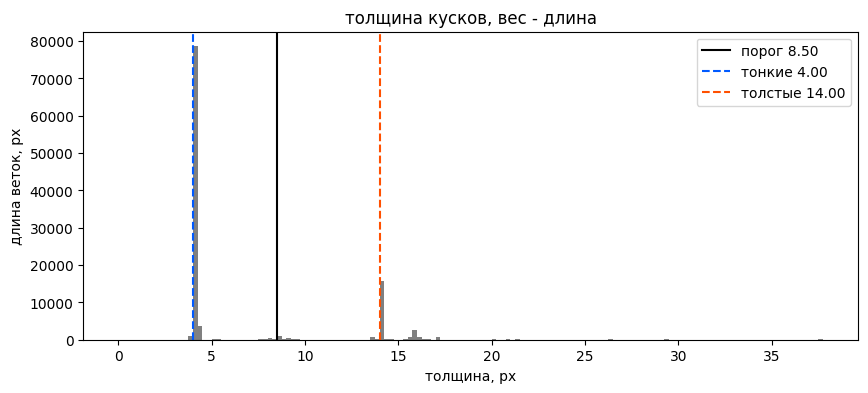

In [2551]:
p = res.pieces
plot_hist(p.thickness.to_numpy(), p.length.to_numpy(), st["bound"],
          (st["thin"], st["thick"]), "толщина кусков, вес - длина")

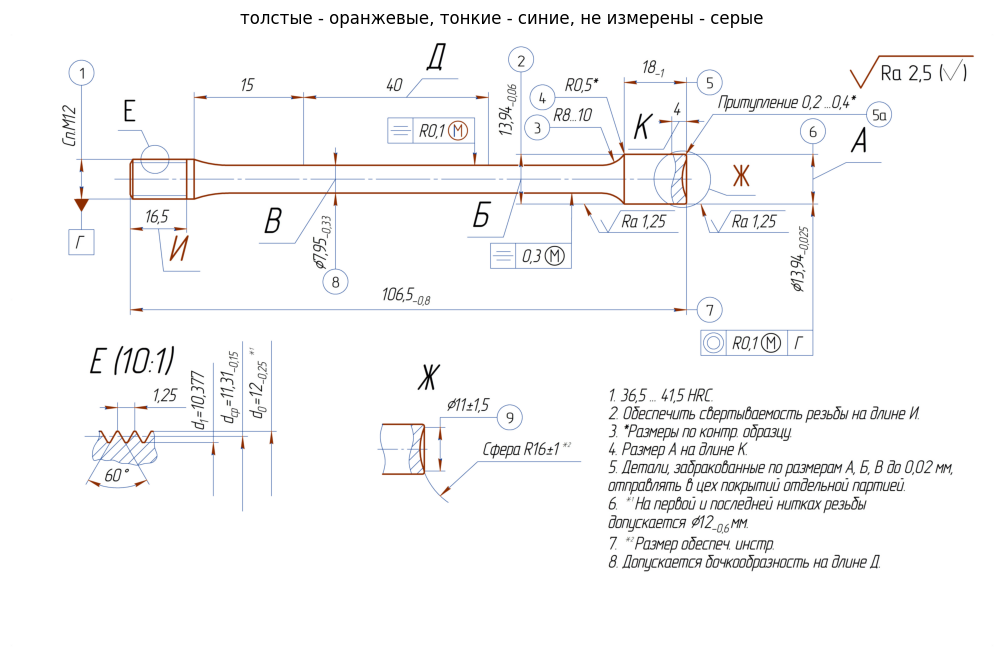

In [2552]:
show(overlay(res.img, res.ink_lbl, res.pieces.group.to_numpy()),
     "толстые - оранжевые, тонкие - синие, не измерены - серые")

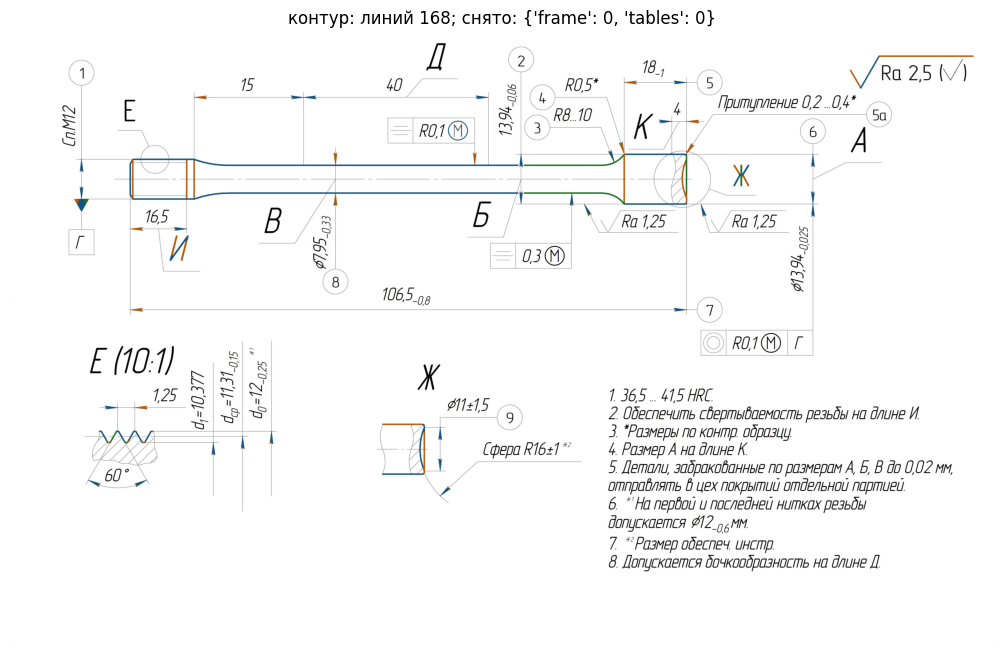

In [2553]:
# Контур: линии, собранные по соосности на скелете толстой краски, - соседние по стыку разного цвета;
# тонкая краска - серая.
c = res.contour
color = chain_colors(c)
pal = plt.cm.tab10(np.arange(10))[:, :3] * 255
col = np.full((len(c), 3), 200.0)
has = c.chain.to_numpy() >= 0
col[has] = pal[[color[k] for k in c.chain[has]]]
out = res.img.astype(np.float32)
thin = res.ink & (res.contour_lbl < -1)
out[thin] = out[thin] * 0.3 + 200 * 0.7
for name, rgb in RULE_COLOR.items():  # снятое правилом - его цветом
    col[(c.removed == name).to_numpy()] = rgb
m = res.contour_lbl >= 0
out[m] = out[m] * 0.3 + col[res.contour_lbl[m]] * 0.7
removed = {k[8:]: v for k, v in st.items() if k.startswith("removed_")}
show(out.astype(np.uint8), f"контур: линий {st['chains']}; снято: {removed}")

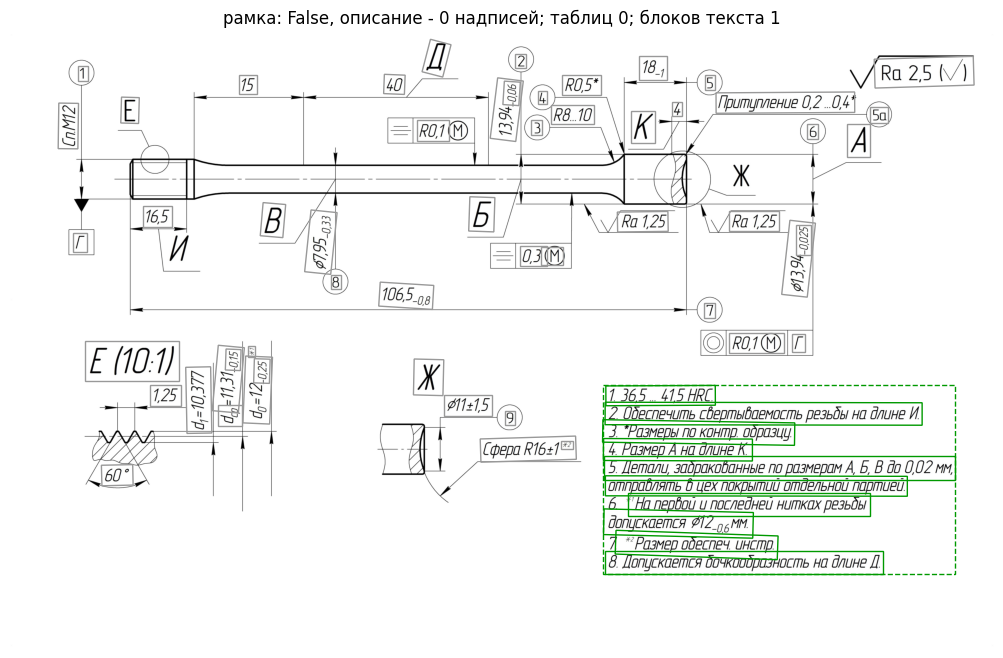

In [2554]:
# Метаданные: полигоны OCR описания рамки - фиолетовые, значений таблиц - красные, блоков текста - зелёные,
# остальные - серые; bbox рамки, таблиц и блоков текста - пунктиром.
from matplotlib.patches import Polygon, Rectangle

meta, polys = res.meta, res.polys
role = np.zeros(len(polys), int)
role[meta["border"]["texts"]] = 1
for tb in meta["tables"]:
    role[tb["texts"]] = 2
for tb in meta["text_blocks"]:
    role[tb["texts"]] = 3
colors = ["0.6", (0.47, 0, 0.78), (0.9, 0, 0), (0, 0.6, 0)]
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(res.img)
for p, k in zip(polys, role):
    ax.add_patch(Polygon(p, closed=True, fill=False, ec=colors[k], lw=1))
boxes = ([(meta["border"]["bbox"], 1)] if meta["border"]["present"] else []) + \
        [(tb["bbox"], 2) for tb in meta["tables"]] + [(tb["bbox"], 3) for tb in meta["text_blocks"]]
s = res.scale
for (x0, y0, x1, y1), k in boxes:
    ax.add_patch(Rectangle((x0 * s, y0 * s), (x1 - x0) * s, (y1 - y0) * s, fill=False, ls="--", ec=colors[k], lw=1))
ax.set_title(f"рамка: {meta['border']['present']}, описание - {len(meta['border']['texts'])} надписей; "
             f"таблиц {len(meta['tables'])}; блоков текста {len(meta['text_blocks'])}")
ax.axis("off")
plt.show()

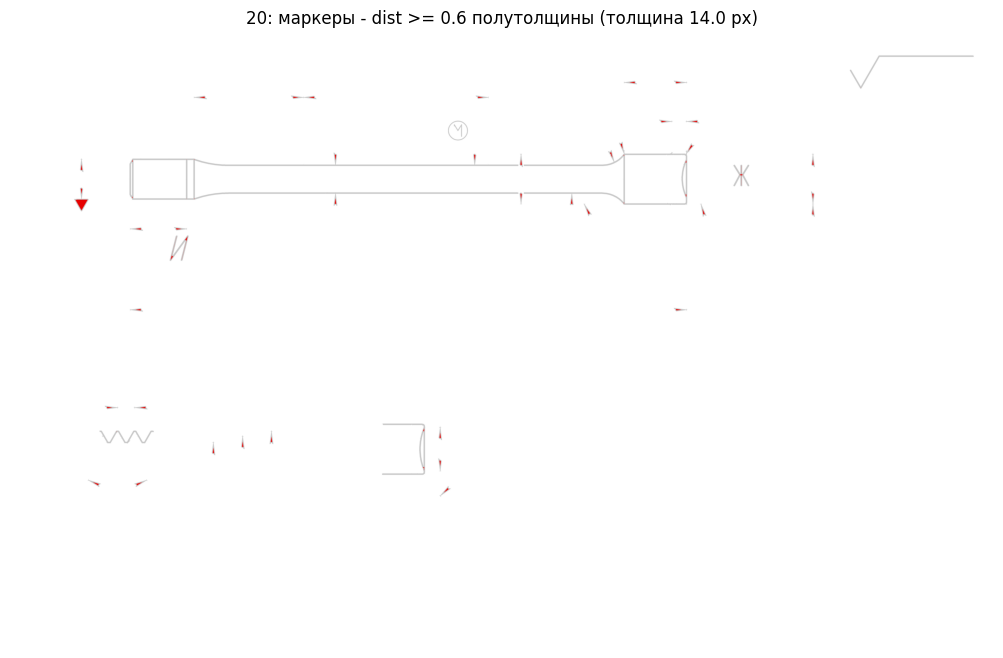

In [2558]:
# Наконечники - самые толстые места толстой краски (красные) поверх оставшихся толстых линий (чёрные).
m = res.contour_lbl >= 0
lines = np.zeros(res.contour_lbl.shape, bool)
lines[m] = res.contour.chain.to_numpy()[res.contour_lbl[m]] >= 0
out = np.full((*lines.shape, 3), 255, np.uint8)
# Маркеры - самое толстое: пикселы дальше c полутолщин толстой линии от края краски.
# Линия толщиной w: в её середине dist ~ w/2, поэтому при c > 1 линия пропадает, а основания
# наконечников (шире линии) - нет. Порог сам подстраивается под лист: толщина - из кластеризации.
C_CORE = 0.6  # ваши 5 итераций 3x3 на листе 19 (толстая ~7.5 px в x2) - это ~1.33

thick_px = res.stats["thick"] * res.scale        # толщина толстой линии, px масштаба листа
dist = cv2.distanceTransform(lines.astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
core = dist >= C_CORE * thick_px

out = np.full((*lines.shape, 3), 255, np.uint8)
out[lines] = (200, 200, 200)
out[core] = (230, 0, 0)
show(out, f"{st['sheet']}: маркеры - dist >= {C_CORE} полутолщины (толщина {thick_px:.1f} px)")


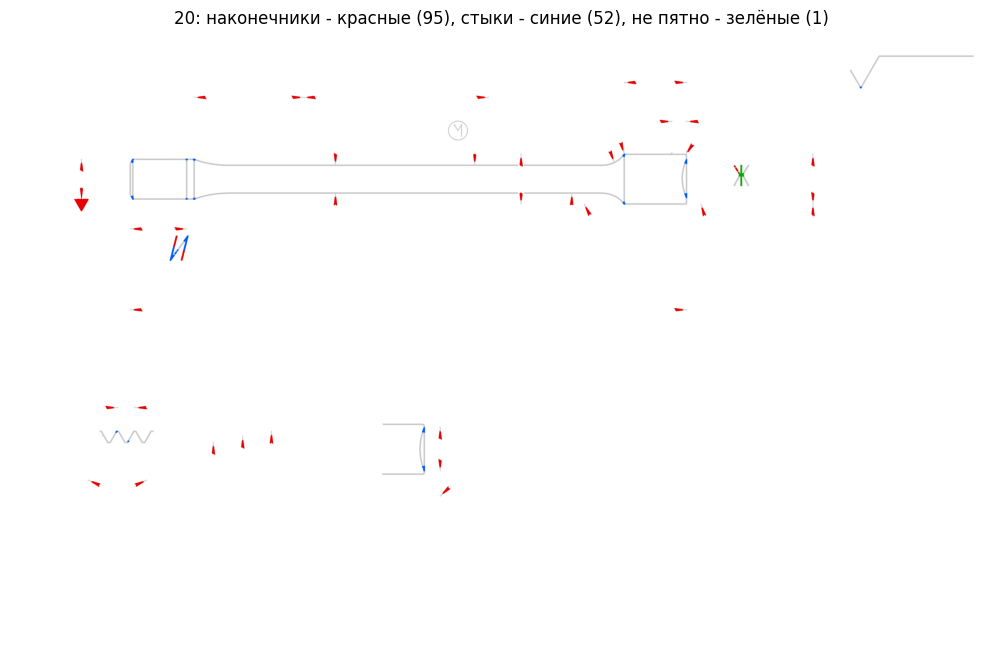

In [2559]:
# Проверка на разрез: тело маркера (круги радиусом dist вокруг него) вырезается из линий, и в окне
# вокруг считается, сколько кусков линий доходит до края окна. Стык лежит на пути контура: после
# вырезания контур распадается - кусков у края становится больше. Наконечник висит на контуре: контур
# остаётся целым, отваливается только острие, а оно до края окна не доходит.
CUT_MARGIN = 7  # окно - тело маркера плюс столько толщин толстой линии с каждой стороны


def border_pieces(mask):
    """Сколько связных кусков маски касаются края окна."""
    _, lb = cv2.connectedComponents(mask.astype(np.uint8), connectivity=8)
    edge = np.unique(np.r_[lb[0], lb[-1], lb[:, 0], lb[:, -1]])
    return int((edge > 0).sum())


n, lab, stc, _ = cv2.connectedComponentsWithStats(core.astype(np.uint8), connectivity=8)
H, W = lines.shape
M = int(CUT_MARGIN * thick_px)
ELONG_MAX = 10.0  # ядро наконечника - пятно: длинная сторона minAreaRect не больше стольких коротких
SOLID_MIN = 0.8  # и сплошное: площадь ядра к площади выпуклой оболочки не меньше (кольцо, дуга - меньше)

kind = np.zeros(n, int)  # 1 - наконечник, 2 - часть контура (разрез), 3 - не пятно (форма)
shape = {}
bodies = np.zeros(lines.shape, bool)
contour_bodies = np.zeros(lines.shape, bool)
form_bodies = np.zeros(lines.shape, bool)
for k in range(1, n):
    x, y, w, h = stc[k, :4]
    R = int(np.ceil(dist[y:y + h, x:x + w][lab[y:y + h, x:x + w] == k].max()))
    y0, y1 = max(0, y - R - M), min(H, y + h + R + M)
    x0, x1 = max(0, x - R - M), min(W, x + w + R + M)
    win = lines[y0:y1, x0:x1]
    marker = (lab[y0:y1, x0:x1] == k).astype(np.uint8)

    # форма ядра: вытянутость и сплошность
    pts = cv2.findNonZero(marker)
    (_, _), (a, b), _ = cv2.minAreaRect(pts)
    elong = max(a, b) / max(min(a, b), 1.0)  # ядро в 1-2 px - короткая сторона не меньше 1
    hull = cv2.contourArea(cv2.convexHull(pts))
    solid = len(pts) / max(hull, len(pts))  # у ядра из 1-2 px оболочка нулевая - считаем сплошным
    shape[k] = (round(elong, 1), round(solid, 2))

    disk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * R + 1, 2 * R + 1))
    body = (cv2.dilate(marker, disk) > 0) & win
    cut = cv2.dilate(body.astype(np.uint8), np.ones((3, 3), np.uint8)) > 0
    if border_pieces(win & ~cut) > border_pieces(win):
        kind[k] = 2
    elif elong > ELONG_MAX or solid < SOLID_MIN:
        kind[k] = 3
    else:
        kind[k] = 1
    {1: bodies, 2: contour_bodies, 3: form_bodies}[kind[k]][y0:y1, x0:x1] |= body

out = np.full((*lines.shape, 3), 255, np.uint8)
out[lines] = (200, 200, 200)
out[bodies] = (230, 0, 0)           # наконечник - снимать
out[contour_bodies] = (0, 90, 255)   # часть контура по разрезу - не трогать
out[form_bodies] = (0, 170, 0)       # висит, но не пятно (линия, кольцо) - не трогать
show(out, f"{st['sheet']}: наконечники - красные ({(kind == 1).sum()}), стыки - синие ({(kind == 2).sum()}), "
          f"не пятно - зелёные ({(kind == 3).sum()})")

## Весь датасет

Картинки оставшихся толстых линий (чёрные на белом, в размер листа) и таблица - в
`research/results/exp_classifier_lines_v2/`. Лист без кэша OCR пропускается.

In [2557]:
# OUT = Path("../research/results/exp_classifier_lines_v2")
# OUT.mkdir(parents=True, exist_ok=True)

# rows = []
# for f in tqdm(files):
#     try:
#         r = process_auto(f)
#     except FileNotFoundError as e:
#         tqdm.write(f"{f.stem}: пропущен - {e}")
#         continue
#     stem = f.stem.replace(" ", "_")
#     cv2.imwrite(str(OUT / f"{stem}.png"), np.where(clean_lines(r), 0, 255).astype(np.uint8))  # оставшиеся толстые линии
#     rows.append(r.stats)
#     st = r.stats
#     tqdm.write(f"{st['sheet']}: x{st['scale']}, {st['seconds'] + st['t_x1']:.1f} с (признаки {st['t_features']:.1f} с), "
#                f"порог {st['bound']:.2f}, тонкие {st['thin']:.2f}, толстые {st['thick']:.2f}")
#     del r

# sheets = pd.DataFrame(rows)
# sheets.to_csv(OUT / "sheets.csv", index=False)
# sheets